In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Month                                767 non-null    object 
 1   Stations                             767 non-null    object 
 2   BOD (mg/L)                           767 non-null    float64
 3   Dissolved Oxygen (mg/L)              767 non-null    float64
 4   Fecal Coliform, MPN/100ml (Geomean)  767 non-null    float64
 5   pH (units)                           767 non-null    float64
 6   Ammonia (mg/L)                       767 non-null    float64
 7   Nitrate (mg/L)                       767 non-null    float64
 8   Inorganic Phospate (mg/L)            767 non-null    float64
dtypes: float64(7), object(2)
memory usage: 54.1+ KB


<Axes: >

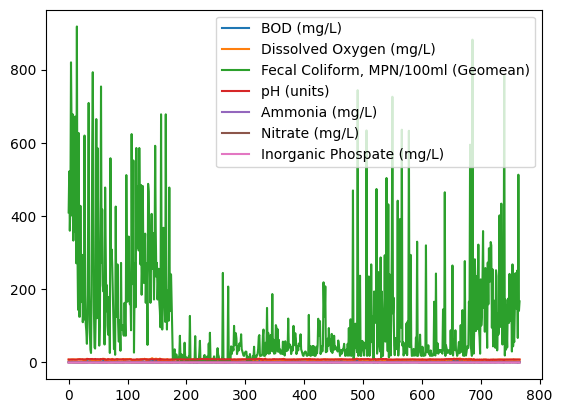

In [3]:
df = pd.read_csv('data.csv')
df.info()

df.plot()

In [4]:
#Change the Month to DateTime format
df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')

In [5]:
stations = df['Stations'].unique()
parameters = df.columns.difference(['Month', 'Stations'])

print("Stations:", stations)
print("Parameters:", parameters)

Stations: ['Stn. II (East Bay)' 'Stn. IV (Central Bay)' 'Stn. V (Northern West Bay)'
 'Stn. VIII (South Bay)' 'Stn. XV (San Pedro)' 'Stn. XVI (Sta. Rosa)'
 'Stn. XVIII (Pagsanjan)' 'Stn. I (Central West Bay)'
 'Stn. XVII (Sanctuary)' 'Stn. XIII (Taytay)' 'Stn. XIX (Muntinlupa)'
 'Stn. XX (GEMS)' 'Stn. XXI (Cardona)' 'Stn. XXII (Jala-jala)'
 'Stn. XXIII (Lumban)']
Parameters: Index(['Ammonia (mg/L)', 'BOD (mg/L)', 'Dissolved Oxygen (mg/L)',
       'Fecal Coliform, MPN/100ml (Geomean)', 'Inorganic Phospate (mg/L)',
       'Nitrate (mg/L)', 'pH (units)'],
      dtype='object')


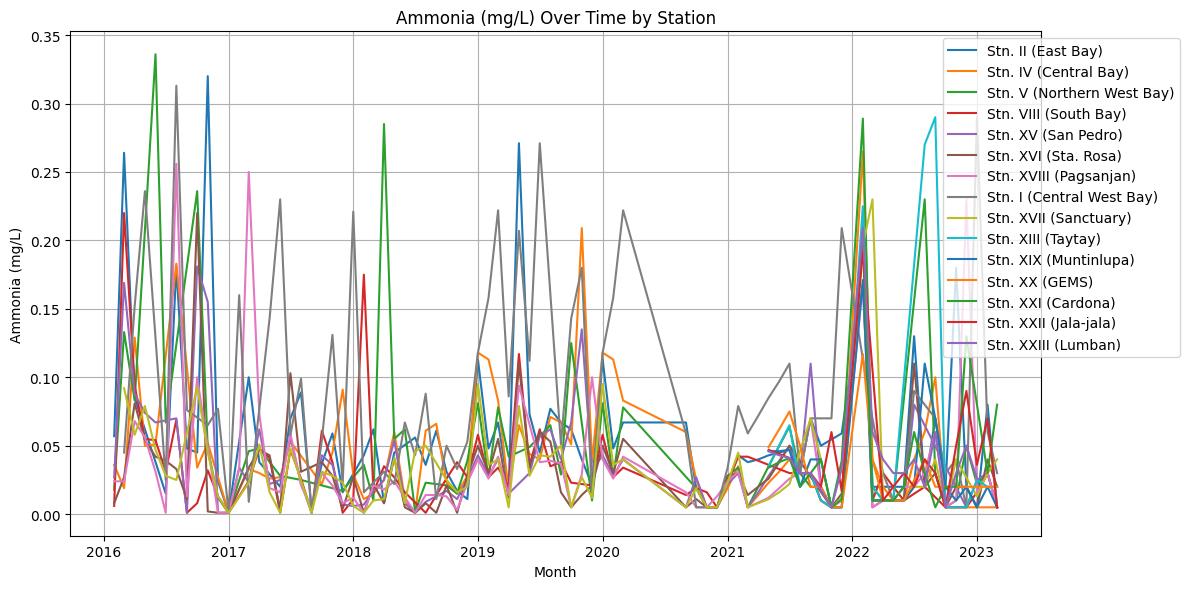

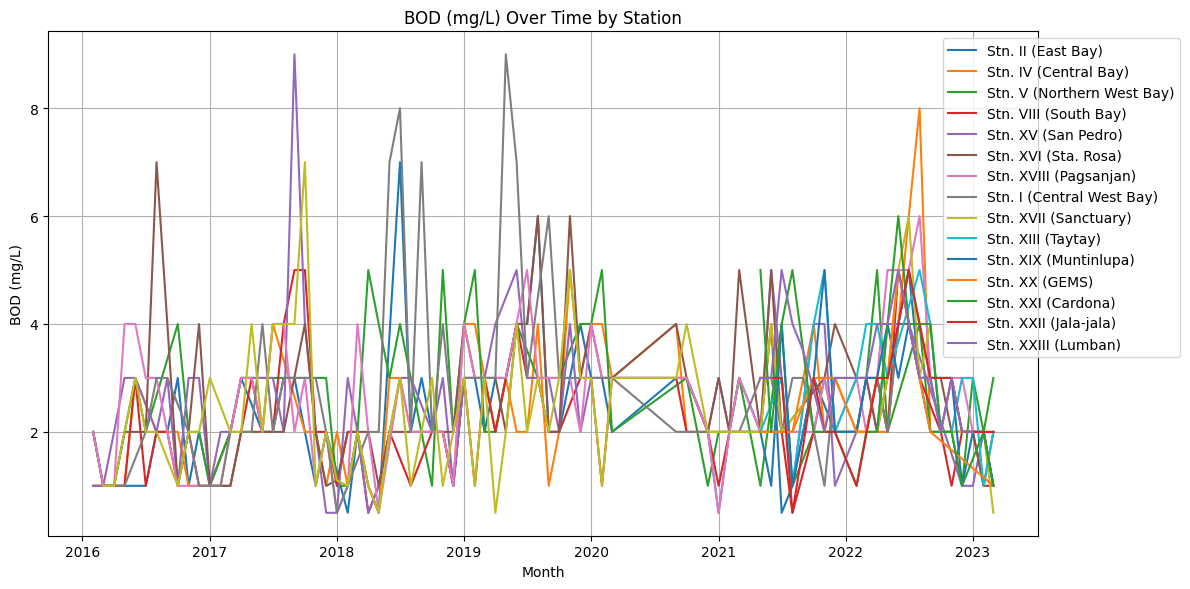

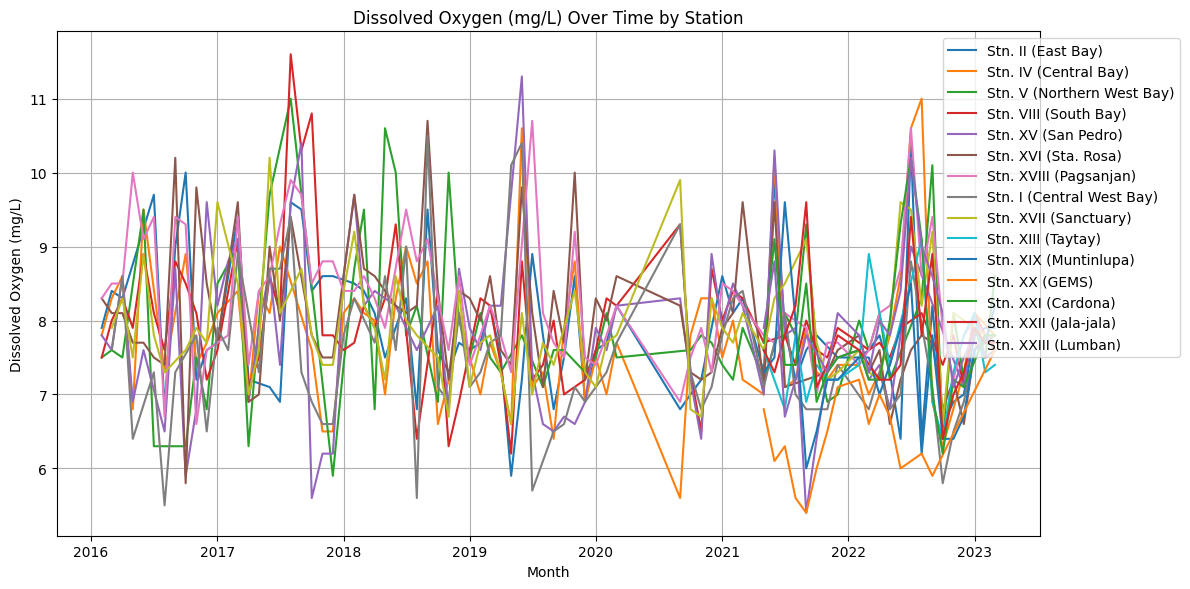

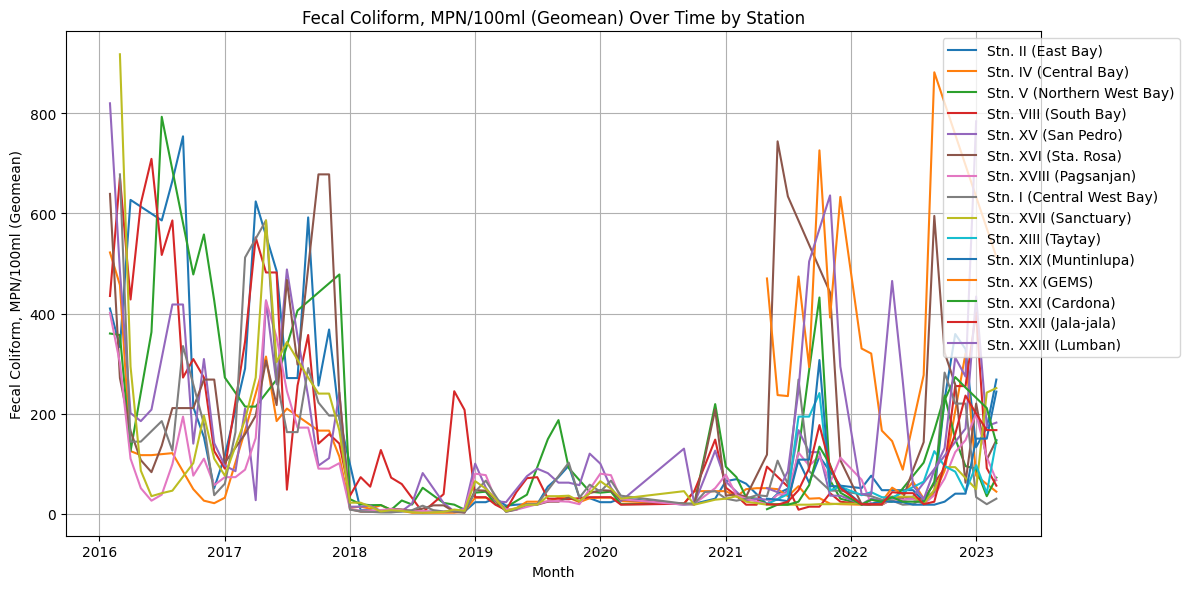

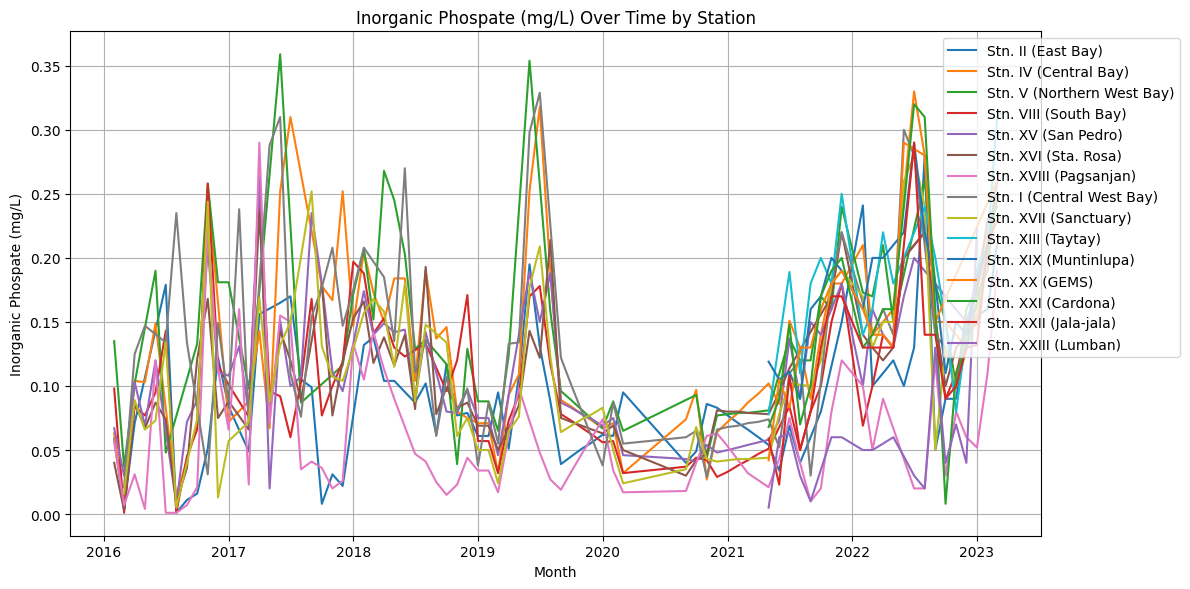

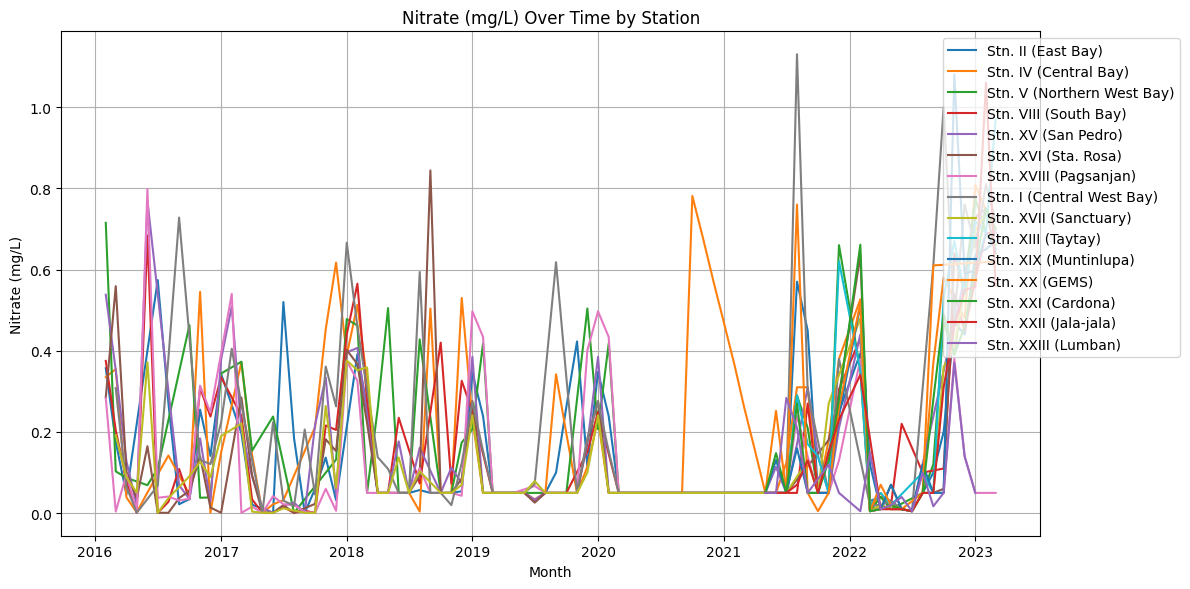

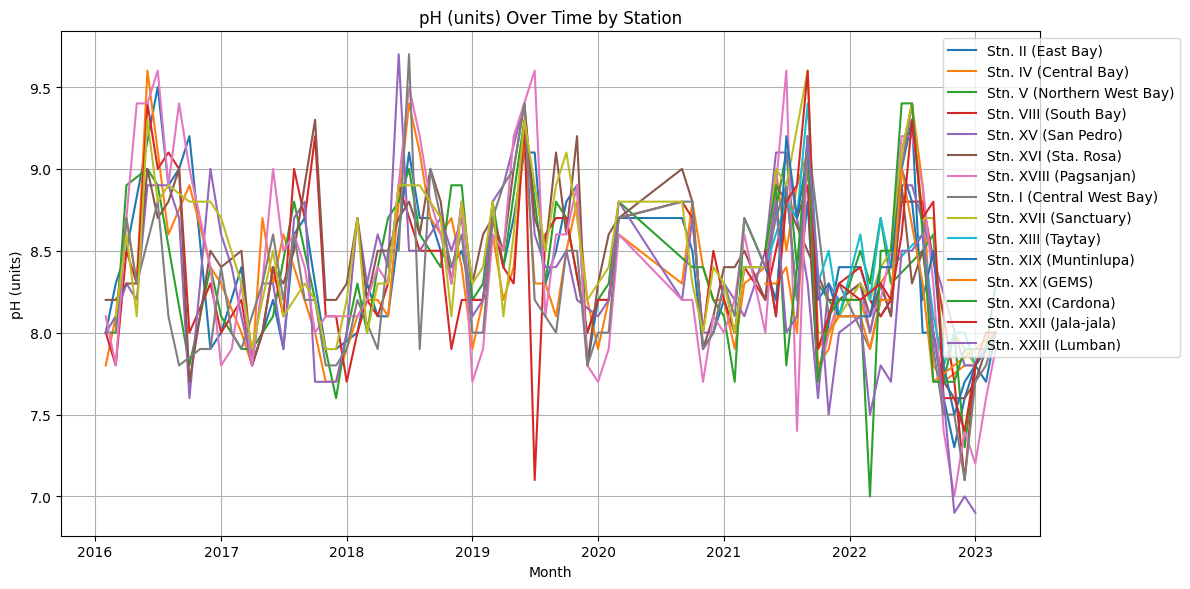

In [32]:
for param in parameters:
    plt.figure(figsize=(12,6))


    for station in stations:
        data = df[df['Stations'] == station]
        plt.plot(data['Month'], data[param], label=station)

        plt.title(f"{param} Over Time by Station")
        plt.xlabel("Month")
        plt.ylabel(param)
        plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
        plt.grid(True)
        plt.tight_layout()

In [ ]:
counts = df.groupby('Stations')[parameters].count()

total_counts = counts.sum(axis=1)

counts['Total Available Data'] = total_counts


print(counts.to_string())
print(counts.to_string(index=True))

                            Ammonia (mg/L)  BOD (mg/L)  Dissolved Oxygen (mg/L)  Fecal Coliform, MPN/100ml (Geomean)  Inorganic Phospate (mg/L)  Nitrate (mg/L)  has_data  pH (units)  Total Available Data
Stations                                                                                                                                                                                                   
Stn. I (Central West Bay)               71          71                       71                                   71                         71              71        71          71                   568
Stn. II (East Bay)                      73          73                       73                                   73                         73              73        73          73                   584
Stn. IV (Central Bay)                   73          73                       73                                   73                         73              73        73          73   

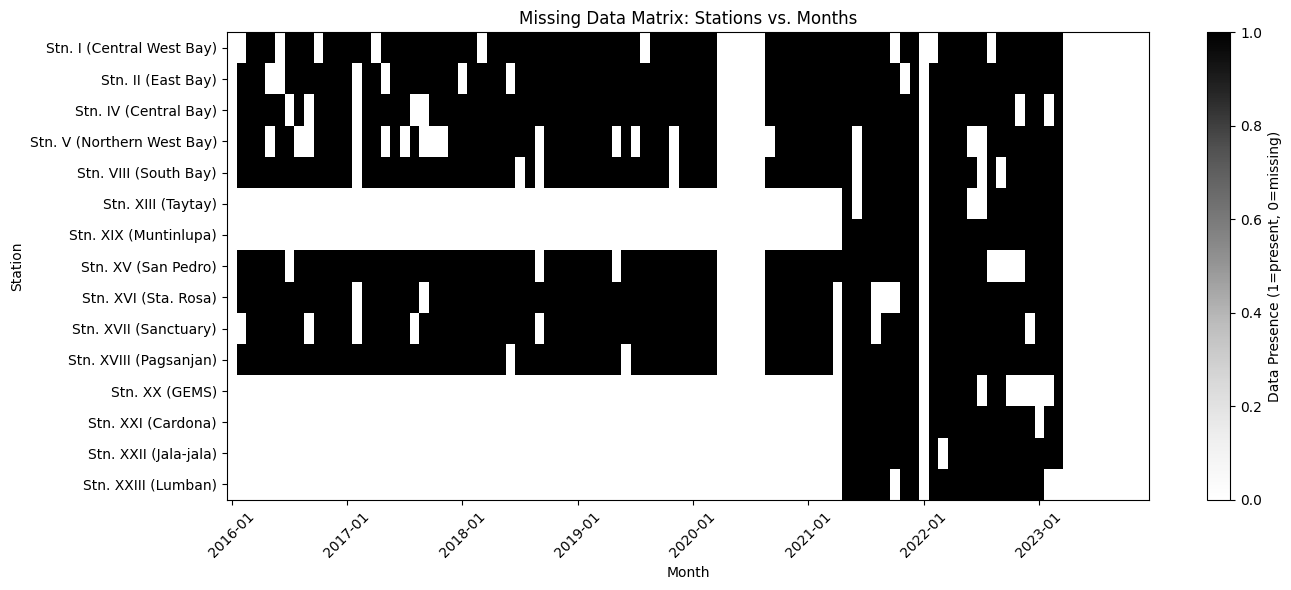

In [ ]:
full_months = pd.date_range(start='2016-01-01', end='2023-12-01', freq='MS')

full_index = pd.MultiIndex.from_product([full_months, stations], names=['Month', 'Stations'])
df_full = pd.DataFrame(index=full_index).reset_index()


df['has_data'] = 1
df_merged = pd.merge(df_full, df[['Month', 'Stations', 'has_data']], on=['Month', 'Stations'], how='left')
df_merged['has_data'] = df_merged['has_data'].fillna(0)


matrix = df_merged.pivot(index='Stations', columns='Month', values='has_data')


plt.figure(figsize=(14, 6))
plt.imshow(matrix, aspect='auto', cmap='Greys', interpolation='none')
plt.colorbar(label='Data Presence (1=present, 0=missing)')
plt.title('Missing Data Matrix: Stations vs. Months')
plt.xlabel('Month')
plt.ylabel('Station')


plt.xticks(
    ticks=np.arange(len(matrix.columns))[::12],
    labels=[d.strftime('%Y-%m') for d in matrix.columns[::12]],
    rotation=45
)
plt.yticks(ticks=np.arange(len(matrix.index)), labels=matrix.index)

plt.tight_layout()
plt.show()


In [ ]:
# changed the months from jan 2016 to dec 2022
expected_months = pd.date_range(start='2016-01-01', end='2023-3-01', freq='MS')
df_expected = df_full[df_full['Month'].isin(expected_months)]

merged = pd.merge(
    df_expected,
    df,
    on=['Month', 'Stations'],
    how='left'
)

parameters = merged.columns.difference(['Month', 'Stations'])

missing_counts = merged.groupby('Stations')[parameters].apply(lambda x: x.isna().sum()).reset_index()
print(missing_counts)

                      Stations  Ammonia (mg/L)  BOD (mg/L)  \
0    Stn. I (Central West Bay)              16          16   
1           Stn. II (East Bay)              14          14   
2        Stn. IV (Central Bay)              14          14   
3   Stn. V (Northern West Bay)              24          24   
4        Stn. VIII (South Bay)              14          14   
5           Stn. XIII (Taytay)              68          68   
6        Stn. XIX (Muntinlupa)              65          65   
7          Stn. XV (San Pedro)              14          14   
8         Stn. XVI (Sta. Rosa)              13          13   
9        Stn. XVII (Sanctuary)              15          15   
10      Stn. XVIII (Pagsanjan)              10          10   
11              Stn. XX (GEMS)              71          71   
12          Stn. XXI (Cardona)              66          66   
13       Stn. XXII (Jala-jala)              66          66   
14         Stn. XXIII (Lumban)              68          68   

    Dis

In [9]:
overall_total_missing = merged[parameters].isna().sum().sum()
print(overall_total_missing)

4304


In [20]:
print(merged.shape[0])

1305


In [8]:
available_counts = merged.groupby('Stations')[parameters].apply(lambda x: x.notna().sum()).reset_index()
print(available_counts)

                      Stations  Ammonia (mg/L)  BOD (mg/L)  \
0    Stn. I (Central West Bay)              71          71   
1           Stn. II (East Bay)              73          73   
2        Stn. IV (Central Bay)              73          73   
3   Stn. V (Northern West Bay)              63          63   
4        Stn. VIII (South Bay)              73          73   
5           Stn. XIII (Taytay)              19          19   
6        Stn. XIX (Muntinlupa)              22          22   
7          Stn. XV (San Pedro)              73          73   
8         Stn. XVI (Sta. Rosa)              74          74   
9        Stn. XVII (Sanctuary)              72          72   
10      Stn. XVIII (Pagsanjan)              77          77   
11              Stn. XX (GEMS)              16          16   
12          Stn. XXI (Cardona)              21          21   
13       Stn. XXII (Jala-jala)              21          21   
14         Stn. XXIII (Lumban)              19          19   

    Dis

In [21]:
overall_available = available_counts[parameters].sum().sum()
print(overall_available)

6136


In [12]:
missing_counts.to_csv("missing_values_per_station.csv", index=False)


available_counts.to_csv("available_values_per_station.csv", index=False)

In [13]:
merged.to_csv("merged_data.csv", index=False)

In [ ]:
merged.head()

,Month,Stations,BOD (mg/L),Dissolved Oxygen (mg/L),"Fecal Coliform, MPN/100ml (Geomean)",pH (units),Ammonia (mg/L),Nitrate (mg/L),Inorganic Phospate (mg/L)
0,2016-01-01,Stn. II (East Bay),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,Stn. IV (Central Bay),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,Stn. V (Northern West Bay),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01,Stn. VIII (South Bay),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01,Stn. XV (San Pedro),NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
###only use Stations I. II, IV, V, VIII, XV, XVI, XVII, XVIII for January 2016 - December 2022
###for Stations XIII, XIX, XX, XXI, XXII, XXIII use January 2021 - December 2022
import pandas as pd

group1_stations = ['Stn. I', 'Stn. II', 'Stn. IV', 'Stn. V', 'Stn. VIII',
                   'Stn. XV', 'Stn. XVI', 'Stn. XVII', 'Stn. XVIII']
group2_stations = ['Stn. XIII', 'Stn. XIX', 'Stn. XX', 'Stn. XXI', 'Stn. XXII', 'Stn. XXIII']

df2 = pd.read_csv("merged_data.csv")
df2['Month'] = pd.to_datetime(df2['Month'])


group1_stations = ['Stn. I', 'Stn. II', 'Stn. IV', 'Stn. V', 'Stn. VIII',
                   'Stn. XV', 'Stn. XVI', 'Stn. XVII', 'Stn. XVIII']
group2_stations = ['Stn. XIII', 'Stn. XIX', 'Stn. XX', 'Stn. XXI', 'Stn. XXII', 'Stn. XXIII']


group1_df = df2[
    (df2['Stations'].str.contains('|'.join(group1_stations))) &
    (df2['Month'] >= '2016-01-01') &
    (df2['Month'] <= '2023-03-31')
]


group2_df = df2[
    (df2['Stations'].str.contains('|'.join(group2_stations))) &
    (df2['Month'] >= '2016-01-01') &
    (df2['Month'] <= '2023-03-31')
]


group1_df.to_csv("group1_filtered2.csv", index=False)
group2_df.to_csv("group2_filtered2.csv", index=False)

In [19]:
df_df1 = pd.read_csv('group1_filtered2.csv')
df_df2 = pd.read_csv('group2_filtered2.csv')

def summarize_data(df, name):
    total_rows = len(df)
    total_available = df.notna().sum().sum()
    total_missing = df.isna().sum().sum()
    
    print(f"Summary for {name}:")
    print(f"Total Rows: {total_rows}")
    print(f"Available Values: {total_available}")
    print(f"Missing Values: {total_missing}")
    print("-" * 40)

# Run summaries
summarize_data(df_df1, "group1_filtered2.csv")
summarize_data(df_df2, "group2_filtered2.csv")

Summary for group1_filtered2.csv:
Total Rows: 783
Available Values: 6758
Missing Values: 1072
----------------------------------------
Summary for group2_filtered2.csv:
Total Rows: 522
Available Values: 1988
Missing Values: 3232
----------------------------------------


In [ ]:
##Data interpolation part chucuchuhcu
group1_df = group1_df.sort_values(['Stations', 'Month'])
group2_df = group2_df.sort_values(['Stations', 'Month'])

def interpolate_numeric_only(group):
    station_name = group['Stations'].iloc[0]
    month = group['Month'].reset_index(drop=True)
    numeric = group.select_dtypes(include='number')

    #Add data linearly that fills missing values
    ##Rounds to 3 decimal places
    numeric_interpolated = numeric.interpolate(method='linear').bfill().ffill().round(3)

    #Reconstruct the full DataFrame
    result = pd.concat([
        month,
        pd.Series([station_name] * len(group), name='Stations'),
        numeric_interpolated.reset_index(drop=True)
    ], axis=1)

    return result

#Apply interpolation per station
group1_df_filled = group1_df.groupby('Stations', group_keys=False).apply(interpolate_numeric_only).reset_index(drop=True)
group2_df_filled = group2_df.groupby('Stations', group_keys=False).apply(interpolate_numeric_only).reset_index(drop=True)

group1_df_filled.to_csv("group1_interpolated_complete.csv", index=False)
group2_df_filled.to_csv("group2_interpolated_complete.csv", index=False)

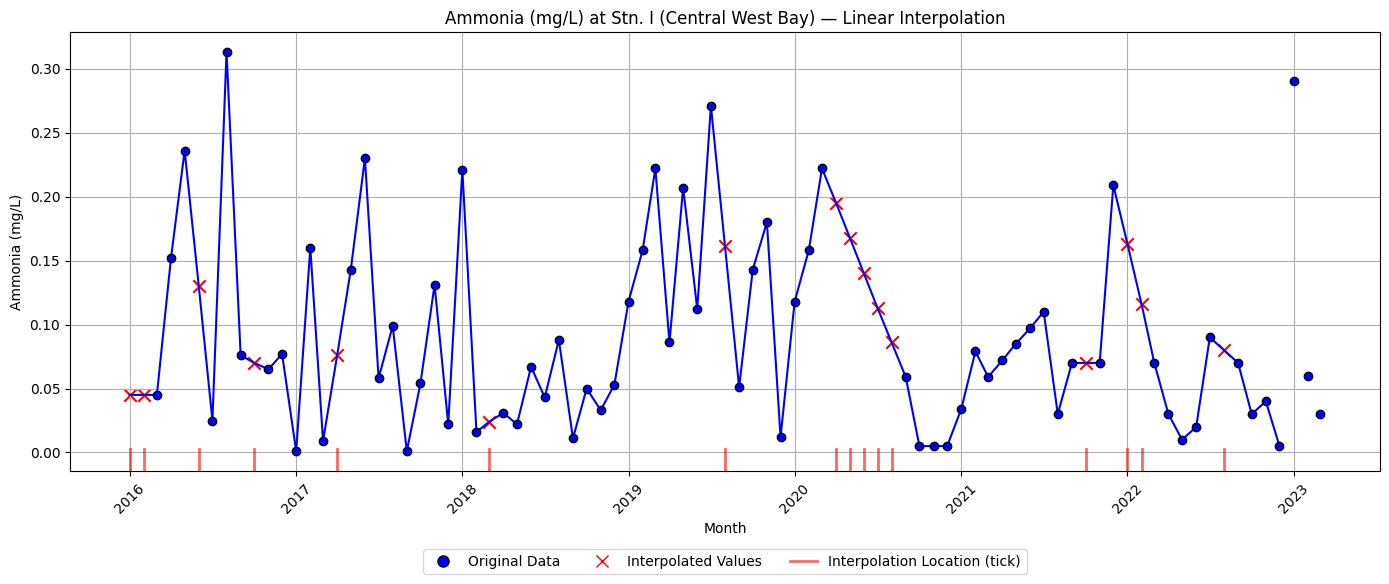

In [ ]:


from matplotlib.lines import Line2D

raw_df = pd.read_csv("data.csv")
interp_df = pd.read_csv("group1_interpolated_complete.csv")


raw_df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')
interp_df['Month'] = pd.to_datetime(interp_df['Month'], errors='coerce')




raw_df['Ammonia (mg/L)'] = pd.to_numeric(raw_df['Ammonia (mg/L)'], errors='coerce')
interp_df['Ammonia (mg/L)'] = pd.to_numeric(interp_df['Ammonia (mg/L)'], errors='coerce')


station_name = "Stn. I (Central West Bay)"
parameter = "Ammonia (mg/L)"
raw_station = raw_df[raw_df['Stations'] == station_name]
interp_station = interp_df[interp_df['Stations'] == station_name]

merged = pd.merge(interp_station[['Month', parameter]],
                  raw_station[['Month', parameter]],
                  on='Month',
                  how='left',
                  suffixes=('_interp', '_raw'))

interpolated = merged[merged[f"{parameter}_raw"].isna()]


plt.figure(figsize=(14, 6))
plt.plot(interp_station['Month'], interp_station[parameter], color='blue', label='Interpolated Line')
plt.scatter(raw_station['Month'], raw_station[parameter], color='blue', edgecolor='black', zorder=5, label='Original Data')
plt.scatter(interpolated['Month'], interpolated[f"{parameter}_interp"], color='red', marker='x', s=80, label='Interpolated Values')

for x in interpolated['Month']:
    plt.axvline(x=x, ymin=0, ymax=0.05, color='red', linewidth=2, alpha=0.6)

custom_lines = [

    Line2D([0], [0], marker='o', color='w', label='Original Data',
           markerfacecolor='blue', markeredgecolor='black', markersize=8),

    Line2D([0], [0], marker='x', color='red', linestyle='None', markersize=8, label='Interpolated Values'),
    Line2D([0], [0], color='red', lw=2, alpha=0.6, label='Interpolation Location (tick)')
]

plt.legend(handles=custom_lines, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.title(f"{parameter} at {station_name} — Linear Interpolation")
plt.xlabel("Month")
plt.ylabel(parameter)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()